<a href="https://colab.research.google.com/github/RafaelCaballero/BME/blob/main/mfia/kmeans_ibex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table>
<tr>
<td><img src="https://www.institutobme.es/dam/layout/bme-logo.svg" width="150"></td>
<td><table><tr><td><h1>KMeans- Ejemplo</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>

</tr>
</table>


In [30]:
import pandas as pd

file = "https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/datos_ibex.xlsx"

df = pd.read_excel(file)
close = [c for c in df.columns if "close" in c]
df = df[close].dropna().reset_index(drop=True).T

In [31]:

df

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
acs_close,1.214988,0.939466,0.103432,0.619808,0.102688,0.923075,0.203247,0.101417,0.709212,0.201213,...,2.911872,-3.052873,-0.230415,-0.615848,-0.929514,0.211059,1.900233,-3.574202,-0.966960,1.301870
acerinox_close,0.492604,-0.490190,0.591115,-0.293805,1.964632,0.000000,0.385362,0.191926,1.149431,-0.568184,...,-0.775200,-0.901440,-3.699210,-0.629725,-0.950568,-3.071020,1.188121,-0.195693,3.202613,3.229888
aena_close,0.173710,0.231218,0.980400,-0.685340,1.150099,1.137010,1.630131,0.442473,-0.330393,-1.215480,...,-0.524349,-0.301205,2.794561,1.028658,-0.727276,0.073262,-2.415812,0.075020,1.724134,1.473845
amadeus_close,-0.503699,0.573736,3.355708,0.779228,0.289937,1.445560,1.836605,0.528613,1.546553,-0.121842,...,-0.504073,1.909584,-0.229443,-0.038327,-0.038349,-0.728807,-1.313746,2.376662,0.195088,-0.506235
acciona_close,0.175586,1.840490,0.516360,0.599317,3.148926,-1.072598,1.584653,1.724137,0.322842,-1.448115,...,1.137974,-2.039377,-2.368990,-1.691179,0.747943,1.336305,1.538466,-1.659454,-1.467351,1.787039
accionaenergia_close,-0.891075,3.296692,0.096717,2.512071,2.827515,-0.641609,1.937267,0.995472,-0.268804,-1.437558,...,2.640549,-1.908718,-0.592214,-1.531917,0.432154,-0.516347,0.086499,-2.679339,1.065718,1.757468
bbva_close,-0.101519,3.607706,0.931846,-6.705534,1.145828,0.144172,1.809965,3.030288,-2.215669,0.461188,...,1.921274,-0.275860,-1.705859,1.735464,-1.014298,0.372613,1.484926,0.365798,2.232345,1.336895
bankinter_close,-0.162310,2.357101,-0.529394,-0.957953,1.692639,-0.369878,0.928135,0.026271,-1.365899,2.370175,...,1.716050,-1.450232,-3.076923,-0.103515,0.863558,-0.205484,0.480444,0.512294,2.038737,0.432898
caixabank_close,2.355429,1.438245,-0.303831,-0.893949,1.025013,-0.243515,0.813674,-1.614213,-1.127948,1.368988,...,0.593118,-0.943395,-1.825401,0.040421,-0.525249,-0.731114,1.350245,0.928541,0.959999,0.237716
cellnex_close,-0.822680,0.890942,0.091344,0.912689,0.934579,-1.284329,2.360053,2.955961,0.545503,0.685307,...,1.159929,-1.250871,2.040816,-2.344829,-1.024008,-4.530861,-2.279524,-1.950288,2.067085,1.948797


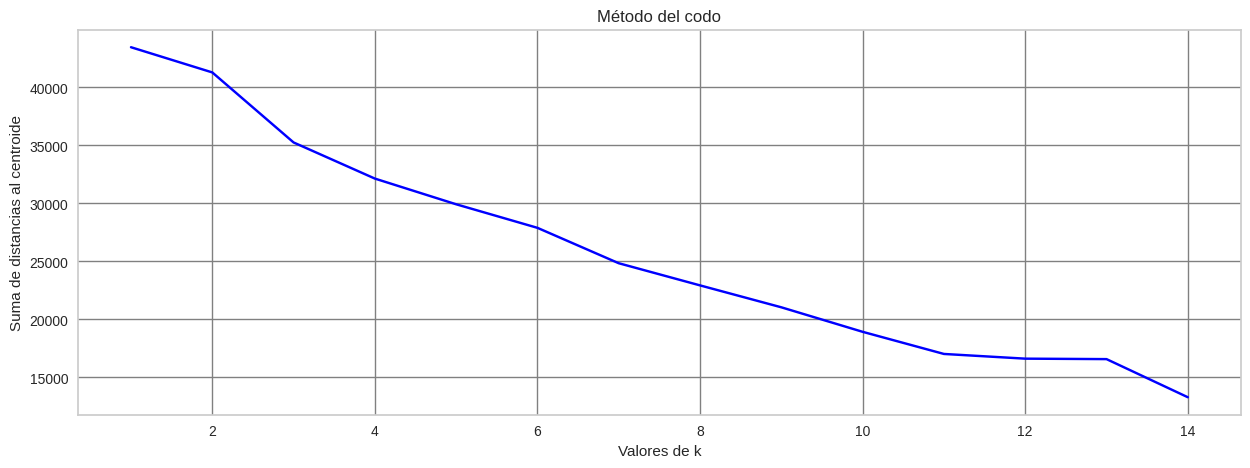

In [32]:
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


feat_cols = df.columns
suma_de_cuadrados = []
K = range(1,15)
for k in K:
    kmeans = KMeans(n_clusters=k,n_init='auto')
    kmeans.fit_transform(df[feat_cols])
    suma_de_cuadrados.append(kmeans.inertia_)

# dibujamos la gráfica
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(K, suma_de_cuadrados,color="blue")
ax.set_xlabel('Valores de k')
ax.set_ylabel('Suma de distancias al centroide')
ax.grid( which='major', color='gray', linestyle='-')
plt.title('Método del codo')
plt.show()

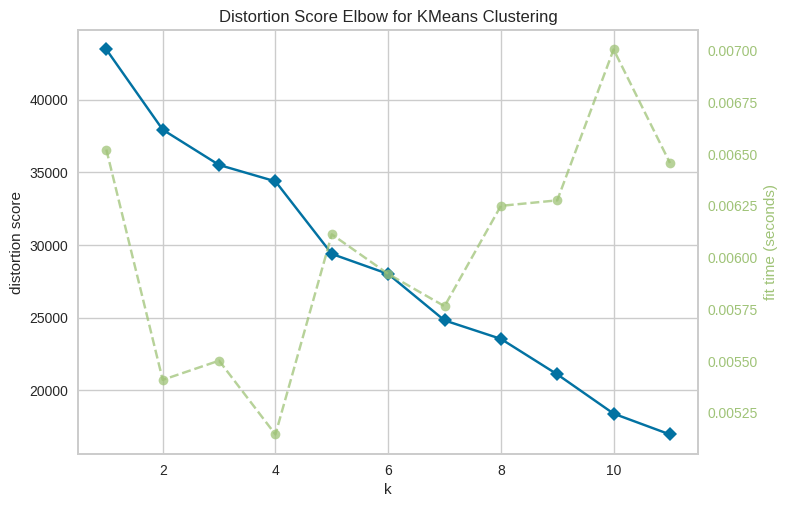

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn import preprocessing
from yellowbrick.cluster import KElbowVisualizer


df2 =  df[feat_cols]  # df2 es df restringido a las variables de interés


# Modelo y visualizador
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))

visualizer.fit(df2)      # Fit the data to the visualizer
visualizer.show()

In [42]:
k=8
model = KMeans( n_clusters=k)
model.fit_transform(df[feat_cols])

df2 = df.copy()
df2["C"] = model.labels_

In [43]:
for i in range(k):
  filtro = df2["C"]==i
  print(df2[filtro].index)

Index(['bbva_close', 'bankinter_close', 'caixabank_close',
       'arcelormittal_close', 'sabadell_close', 'santander_close',
       'unicaja_close'],
      dtype='object')
Index(['cellnex_close'], dtype='object')
Index(['acs_close', 'acerinox_close', 'aena_close', 'fluidra_close',
       'ferrovial_close', 'iag_close', 'inditex_close', 'merlin_close',
       'sacyr_close'],
      dtype='object')
Index(['solaria_close'], dtype='object')
Index(['amadeus_close', 'colonial_close', 'endesa_close', 'enagas_close',
       'iberdrola_close', 'logista_close', 'mapfre_close', 'naturgy_close',
       'puig_close', 'redeia_close', 'repsol_close', 'rovi_close',
       'telefonica_close'],
      dtype='object')
Index(['indra_close'], dtype='object')
Index(['grifols_close'], dtype='object')
Index(['acciona_close', 'accionaenergia_close'], dtype='object')


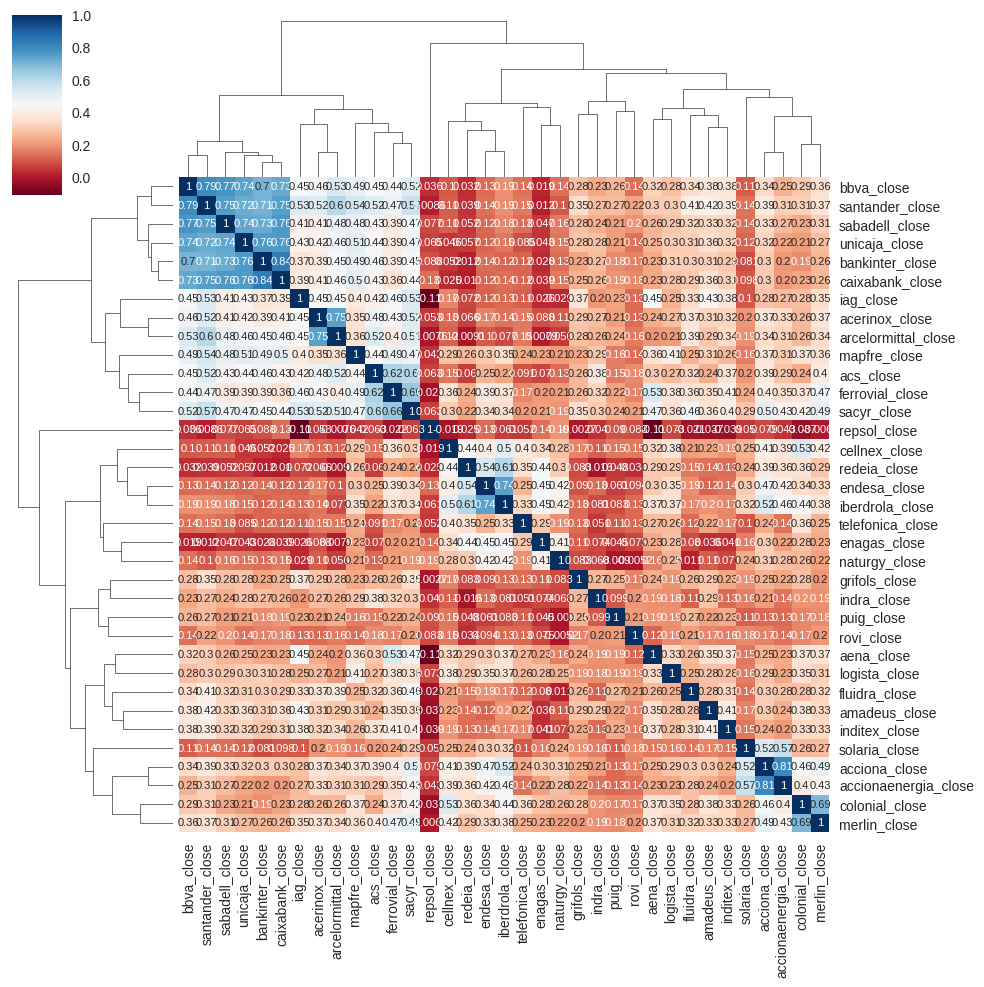

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

file = "https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/datos_ibex.xlsx"

df3 = pd.read_excel(file)
close = [c for c in df3.columns if "close" in c]
df3 = df3[close].dropna().reset_index(drop=True)

g = sns.clustermap(df3.corr(),
                   method = 'complete',
                   cmap   = 'RdBu',
                   annot  = True,
                   annot_kws = {'size': 8})